In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
import random
import matplotlib.pyplot as plt

import torchtext.data as data
from torchtext.data import Field, LabelField
from torchtext.data import BucketIterator
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

In [2]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Загрузка датасета
df = pd.read_csv('FakeNewsNet.csv')  # Замените на путь к вашему файлу
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка на null-значения
print(df.isnull().sum())
df.dropna(inplace=True)

# Проверка баланса классов
print(df['real'].value_counts())

# Комбинирование текстов
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64


In [4]:
# Определите поля (fields)
TEXT = data.Field(sequential=True, tokenize='spacy', lower=True, tokenizer_language='en_core_web_sm')
LABEL = data.LabelField(dtype=torch.float)

In [5]:
# Создайте список примеров
examples = []
for index, row in df.iterrows():
    text = row['text']
    label = row['real']
    examples.append(data.Example.fromlist([text, label], fields=[('text', TEXT), ('label', LABEL)]))

In [6]:
# Создайте Dataset
dataset = data.Dataset(examples, fields=[('text', TEXT), ('label', LABEL)])

In [7]:
# Задайте seed для воспроизводимости
SEED = 42
random.seed(SEED)

# Разбейте на тренировочный и тестовый наборы данных
train_data, test_data = dataset.split(split_ratio=0.8, random_state=random.seed(SEED))

In [8]:
# Построение словаря
TEXT.build_vocab(train_data)
LABEL.build_vocab(train_data)

In [9]:
# Определение BATCH_SIZE
BATCH_SIZE = 30


In [10]:
# Создаём итератор
train_iterator, test_iterator = BucketIterator.splits(
    (train_data, test_data),
    batch_size=BATCH_SIZE,
    device=device,
    sort_within_batch=True,
    sort_key=lambda x: len(x.text))

In [75]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, dropout = dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.rnn(embedded)  
        hidden = self.dropout(hidden[-1,:,:])
        return self.fc(hidden.squeeze(0)) 

In [89]:
class LSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1, :, :])
        return self.fc(hidden)

In [90]:
class GRU(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1, :, :])
        return self.fc(hidden)

In [103]:
def train_model(model, train_iterator, optimizer, criterion, epochs):
    """Обучает модель RNN, LSTM или GRU."""

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in tqdm(range(epochs)):
        epoch_loss = 0
        epoch_acc = 0
        model.train()

        all_predictions = []
        all_labels = []

        for batch in train_iterator:
            optimizer.zero_grad()
            predictions = model(batch.text).squeeze()
            loss = criterion(predictions, batch.label)
            acc = binary_accuracy(predictions, batch.label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

            all_predictions += predictions.tolist()
            all_labels += batch.label.tolist()
            
        all_predictions = torch.tensor(all_predictions)
        all_labels = torch.tensor(all_labels)
        val_acc = binary_accuracy(all_predictions, all_labels)
        val_loss = criterion(all_predictions, all_labels).item()

        train_losses.append(epoch_loss / len(train_iterator))
        train_accuracies.append(epoch_acc / len(train_iterator))
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch: {epoch+1:02}, Train Loss: {train_losses[-1]:.3f}, Train Acc: {train_accuracies[-1]*100:.2f}%, Val Loss: {val_losses[-1]:.3f}, Val Acc: {val_accuracies[-1]*100:.2f}%')

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
# Определяем параметры модели
INPUT_DIM = len(TEXT.vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
OUTPUT_DIM = 1
N_LAYERS = 1
DROPOUT = 0.5

model_rnn = RNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

# Определяем оптимизатор и функцию потерь
optimizer = optim.Adam(model_rnn.parameters())
criterion = nn.BCEWithLogitsLoss()

model_rnn = model_rnn.to(device)
criterion = criterion.to(device)

In [ ]:
# Вычисляем accuracy
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    all_predictions = []
    all_labels = []

    for batch in iterator:
        optimizer.zero_grad()
        predictions = model(batch.text).squeeze()
        loss = criterion(predictions, batch.label)
        acc = binary_accuracy(predictions, batch.label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

        all_predictions += predictions.tolist()
        all_labels += batch.label.tolist()

    all_predictions = torch.tensor(all_predictions)
    all_labels = torch.tensor(all_labels)
    val_acc = binary_accuracy(all_predictions, all_labels)
    val_loss = criterion(all_predictions, all_labels).item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator), val_loss, val_acc.item()
 

In [ ]:

N_EPOCHS = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in tqdm(range(N_EPOCHS)):
    train_loss, train_acc, val_loss, val_acc = train(model, train_iterator, optimizer, criterion)
    print(f'Epoch: {epoch+1:02}, Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}%, Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%')

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

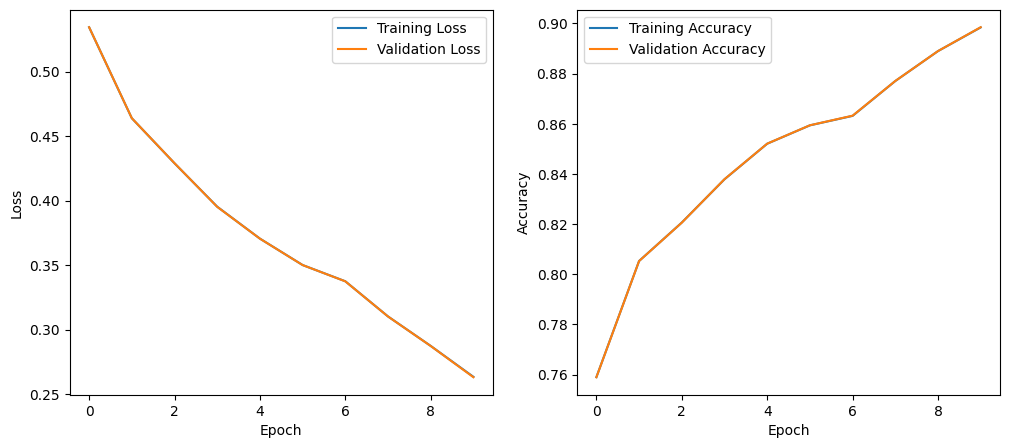

In [87]:
plt.figure(figsize=(12, 5))

#Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# Сохранение модели
# torch.save(model.state_dict(), 'model_pytorch.pt' )

In [88]:
def evaluate_model(model, iterator):
    all_predictions = []
    all_labels = []

    for batch in tqdm(iterator):
        predictions = model(batch.text).squeeze(1)
        all_predictions += predictions.tolist()
        all_labels += batch.label.tolist()

    all_predictions = torch.tensor(all_predictions)
    all_labels = torch.tensor(all_labels)

    y_pred_binary = torch.round(torch.sigmoid(all_predictions)).cpu().numpy()
    y_true = all_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    roc_auc = roc_auc_score(y_true, all_predictions.cpu().numpy())

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("ROC AUC Score:", roc_auc)

    fpr, tpr, _ = roc_curve(y_true, all_predictions.cpu().numpy())
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

100%|██████████| 334/334 [00:01<00:00, 293.53it/s]


Accuracy: 0.8834
F1 Score: 0.8800164642930645
ROC AUC Score: 0.945817524109067


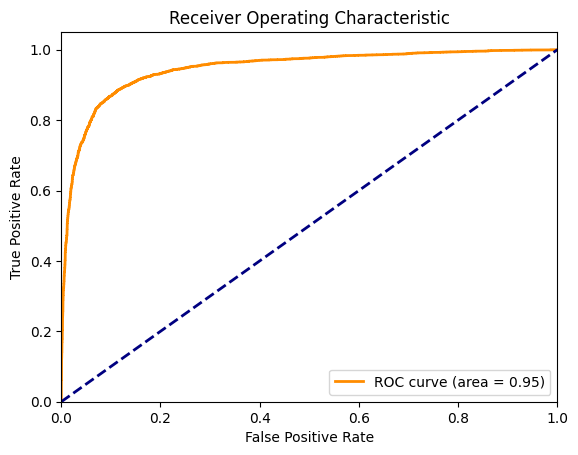

In [ ]:
evaluate_model(model, test_iterator)